# Cutting out a region

`ds.sel(lat=slice(35, 70), lon=slice(-15, 35))` is the line everybody
reaches for first, and on a HEALPix store it raises. There is no `lat`
dimension to slice. There is one horizontal dimension, `cell`, and its index
encodes position in a way that a slice object knows nothing about.

There are two honest ways to cut out a box. The difference between them is
the difference between an analysis that runs in a second and one that
downloads the planet first.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [Cutting out a region](https://waterpark.dkrz.de/docs/examples/03_region_bbox/).*

## The obvious way: mask on the coordinates

Global pyramid levels ship the cell centre coordinates with the store, so
a boolean mask is immediate.

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from healpix_geo import nested

URL = "s3://reanalysis/healpix/era5/P1M/level_7.zarr"
S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}

ds = xr.open_zarr(URL, storage_options=S3, chunks=None)
level = ds.attrs["healpix_level"]
field = ds["tas"].sel(time="2021-07").squeeze()

LON_MIN, LON_MAX = -15.0, 35.0
LAT_MIN, LAT_MAX = 35.0, 70.0

# Coordinates come out of the store in 0..360. A box that crosses the prime
# meridian, which most European boxes do, needs them in -180..180 first.
# This is the most common reason a region comes back empty.
longitude = ds["longitude"].values
longitude = np.where(longitude > 180.0, longitude - 360.0, longitude)
latitude = ds["latitude"].values

inside = (
    (longitude >= LON_MIN) & (longitude <= LON_MAX)
    & (latitude >= LAT_MIN) & (latitude <= LAT_MAX)
)
masked = field.isel(cell=np.flatnonzero(inside))

print(f"{masked.sizes['cell']} of {field.sizes['cell']} cells inside the box")
print(f"regional mean {float(masked.mean()):.2f} K")

Note what the mean did **not** need: no weights. The cells are equal area,
so the arithmetic mean over an arbitrary subset of them is already the
area weighted mean over whatever shape that subset makes.

## What the obvious way costs

The mask is computed from coordinates, which means it needs the
coordinates, which means it needs the store's full cell axis even though
the answer is a few per cent of it.

In [ ]:
print(f"read to build the mask: {field.nbytes / 1e6:.1f} MB")
print(f"actually wanted:        {masked.nbytes / 1e6:.2f} MB")

At level 7 that is a rounding error and the mask is the right answer. At
level 12 it is a gigabyte to select a country, and at level 16 the
coordinate arrays alone would be fifty billion entries, which is why the
regional stores do not carry them at all.

## The scalable way: ask HEALPix which cells the box covers

Invert the question. Instead of reading every cell and testing it, ask the
grid which cell indices cover the box and read only those.

`zone_coverage` is the function for a longitude/latitude rectangle. It
takes the bounding box as `(lon_min, lat_min, lon_max, lat_max)` and
returns a superset of the cells inside it.

In [ ]:
covering, _, fully_inside = nested.zone_coverage(
    (LON_MIN, LAT_MIN, LON_MAX, LAT_MAX), level
)
covering = np.sort(np.asarray(covering).astype("int64"))

print(f"{covering.size} cells cover the box, "
      f"{int(np.sum(fully_inside))} of them lie fully inside it")

> **Warning: Not every coverage function means a lon/lat rectangle**
>
> `nested.box_coverage` looks like it should do this job and does
> something else. It takes a centre and *half* extents, and the box it
> describes is bounded by great circles, which is not the same shape as
> a lon/lat rectangle anywhere away from the equator. Handed this box's
> numbers it returns a region reaching from 43 degrees west to 63 east,
> and still misses cells in the corners. It is the right function for a
> rotated footprint such as a satellite swath, and the wrong one here.
> `nested.cone_coverage` is the circle, which is usually what you want
> around a station or a city.

## Cover, then trim

The coverage is a superset: it includes cells that overlap the boundary
without their centre being inside. The `fully_covered` flag is enough when
you want every cell touching the area, which is the right definition for a
budget or a mask.

When you want the centres, trim it. The point is that the coordinates are
computed for the covered cells only, never for the global axis, so this
step costs the same at level 16 as it does here.

In [ ]:
cover_lon, cover_lat = nested.healpix_to_lonlat(covering.astype("uint64"), level)
cover_lon = np.asarray(cover_lon)
cover_lon = np.where(cover_lon > 180.0, cover_lon - 360.0, cover_lon)
cover_lat = np.asarray(cover_lat)

trimmed = covering[
    (cover_lon >= LON_MIN) & (cover_lon <= LON_MAX)
    & (cover_lat >= LAT_MIN) & (cover_lat <= LAT_MAX)
]

print(f"coordinates computed for {covering.size} cells, "
      f"{100 * covering.size / field.sizes['cell']:.1f}% of the grid")
print(f"trimmed to {trimmed.size} cells; the mask found {masked.sizes['cell']}")
assert set(trimmed.tolist()) == set(np.flatnonzero(inside).tolist())

Identical answers, by two routes that scale very differently.

## Why the reads are cheap too

The indices are not scattered. In nested ordering, cells near each other
on the sphere are near each other in the index, so a compact region
resolves into a handful of contiguous runs, and each run is one byte range
rather than a shopping list.

In [ ]:
runs = np.flatnonzero(np.diff(covering) != 1).size + 1
print(f"{covering.size} indices form {runs} contiguous runs")
print(f"that is {runs} range requests, not {covering.size}")

selected = field.isel(cell=covering)

## The plot

Drawn as cell centres rather than a raster, because at this point the
cells are the subject. At level 7 they are about 50 km across, so they
tile the box densely enough to read as a map. The cells outside the
outline are the coverage's margin, which the trim removes.

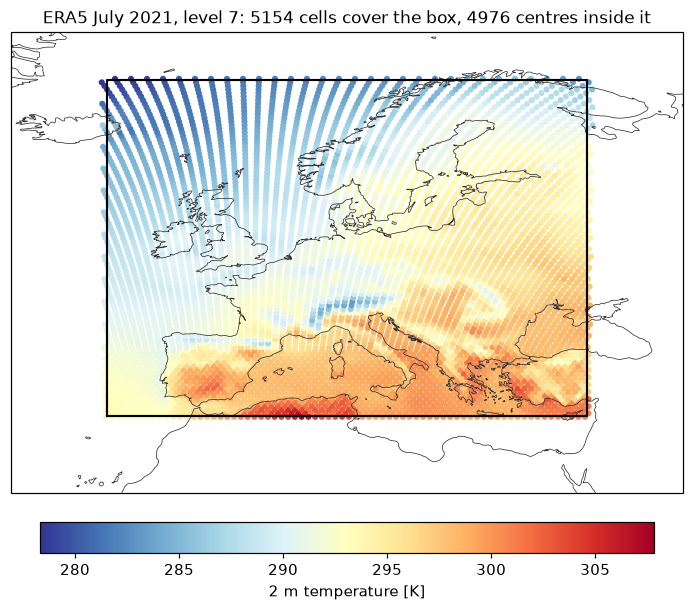

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 6.8), subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.coastlines(linewidth=0.5, color="0.2")
ax.set_extent([LON_MIN - 10, LON_MAX + 10, LAT_MIN - 8, LAT_MAX + 5],
              crs=ccrs.PlateCarree())

scatter = ax.scatter(
    cover_lon, cover_lat, c=selected.values, s=16, cmap="RdYlBu_r",
    edgecolor="none", transform=ccrs.PlateCarree(),
)
ax.plot(
    [LON_MIN, LON_MAX, LON_MAX, LON_MIN, LON_MIN],
    [LAT_MIN, LAT_MIN, LAT_MAX, LAT_MAX, LAT_MIN],
    color="black", lw=1.4, transform=ccrs.PlateCarree(),
)

fig.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8,
             label="2 m temperature [K]")
ax.set_title(
    f"ERA5 July 2021, level {level}: {covering.size} cells cover the box, "
    f"{trimmed.size} centres inside it", fontsize=11,
)

fig.savefig("03_region_bbox.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## Which one to use

Mask on coordinates up to about level 9, where the full cell axis is still
a few million entries and the code is shorter. Above that, cover and trim,
and select **before** you touch any data.

The [regional data guide](https://waterpark.dkrz.de/docs/working-with-data/) works the second
pattern through in full for the city-scale stores at level 16 and above,
where it is not an optimisation but the only thing that works, and where
aligning the cover with the store's chunk size starts to pay as well.